<a href="https://colab.research.google.com/github/ab1991sharma/quantum_study/blob/main/Cohort_1_Session_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Session 4 – Entanglement & Multi-Qubit Systems**


In [ ]:
!pip install qiskit qiskit_aer pylatexenc matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2b3b330d40cc30323fa7a4fed3f7c28c869edcfd45ebb8b894b0627918cfcb32
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Demo 1 – Independent Qubits
Objective

Create two qubits.

Place both into superposition.

Measure them.

Observe that all four outcomes are possible, meaning the qubits behave independently.

Quantum Circuit:



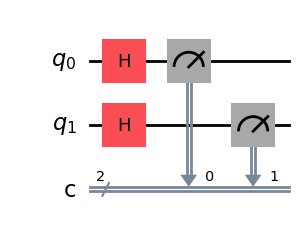

Measurement Counts:
{'00': 220, '10': 268, '11': 272, '01': 264}


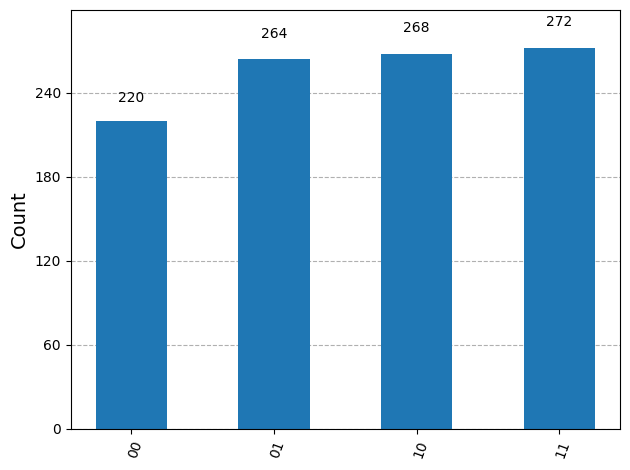

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

# ------------------------------------
# Create a 2-Qubit Quantum Circuit
# ------------------------------------

qc = QuantumCircuit(2, 2)

# Put BOTH qubits into superposition
qc.h(0)
qc.h(1)

# Measure both qubits
qc.measure([0,1], [0,1])

# Display the circuit
print("Quantum Circuit:\n")
display(qc.draw("mpl"))

# ------------------------------------
# Run the simulation
# ------------------------------------

sim = AerSimulator()

result = sim.run(qc, shots=1024).result()

counts = result.get_counts()

print("Measurement Counts:")
print(counts)

# Display histogram
display(plot_histogram(counts))

Demo 2 – Creating a Bell State (Entanglement)
Objective

Create the simplest entangled state using:

Hadamard Gate
CNOT Gate

Observe that the measurement outcomes are correlated.

Bell State Circuit:



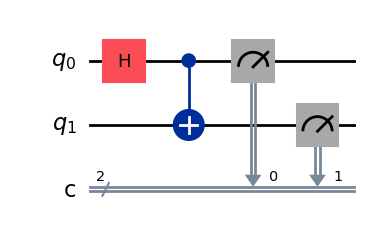

Measurement Counts:
{'11': 535, '00': 489}


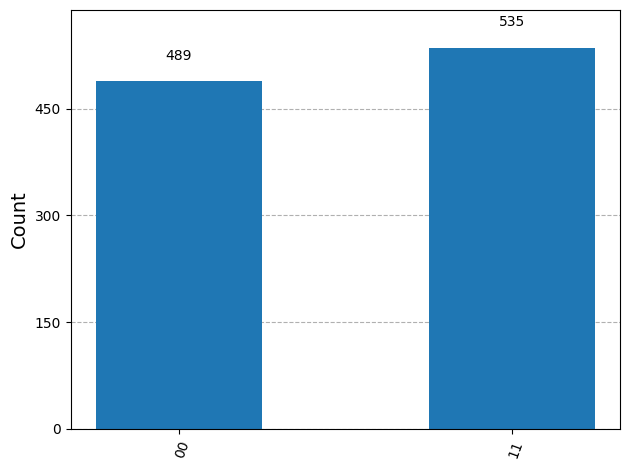

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

# ------------------------------------
# Create Bell State
# ------------------------------------

qc = QuantumCircuit(2, 2)

# Step 1: Create Superposition
qc.h(0)

# Step 2: Entangle the qubits
qc.cx(0, 1)

# Measure
qc.measure([0, 1], [0, 1])

print("Bell State Circuit:\n")
display(qc.draw("mpl"))

# ------------------------------------
# Run Simulation
# ------------------------------------

sim = AerSimulator()

result = sim.run(qc, shots=1024).result()

counts = result.get_counts()

print("Measurement Counts:")
print(counts)

display(plot_histogram(counts))

Demo 3 – What Happens if We Remove the CNOT?
Objective

Compare two nearly identical circuits:

Circuit A: Hadamard + CNOT (Bell State)
Circuit B: Only Hadamard

The goal is to show that removing just one gate changes the behavior from entangled to independent.

Circuit 1 : Bell State


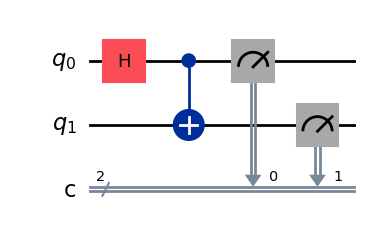

{'00': 528, '11': 496}


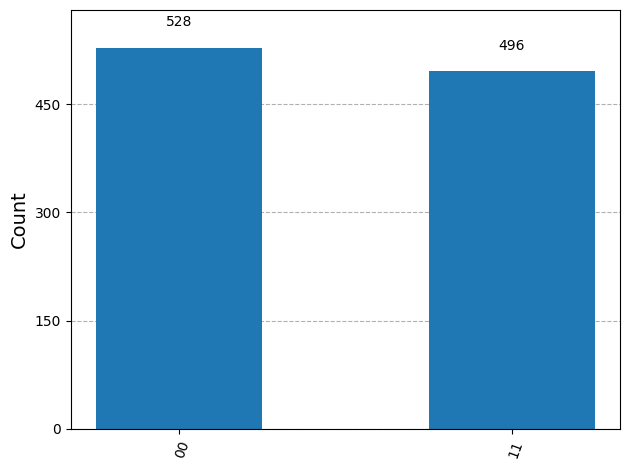


Circuit 2 : Without CNOT


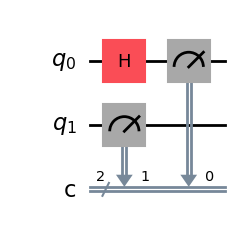

{'00': 514, '01': 510}


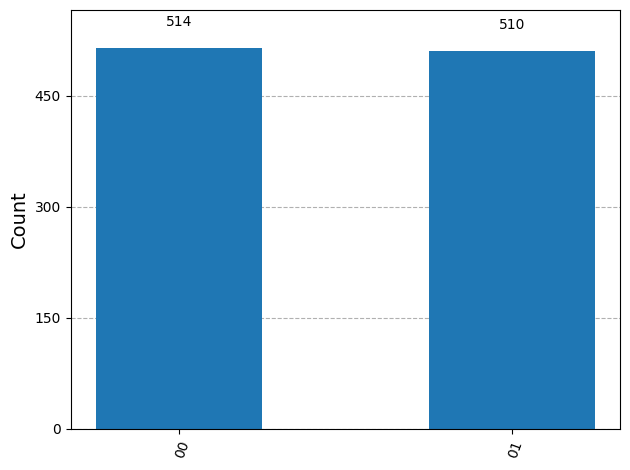

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

sim = AerSimulator()

# ==========================================
# Circuit 1: Bell State (Entangled)
# ==========================================

bell = QuantumCircuit(2, 2)

bell.h(0)
bell.cx(0, 1)

bell.measure([0, 1], [0, 1])

print("Circuit 1 : Bell State")
display(bell.draw("mpl"))

result1 = sim.run(bell, shots=1024).result()
counts1 = result1.get_counts()

print(counts1)
display(plot_histogram(counts1))


# ==========================================
# Circuit 2: Remove the CNOT
# ==========================================

independent = QuantumCircuit(2, 2)

independent.h(0)

# Notice:
# No CNOT Gate

independent.measure([0, 1], [0, 1])

print("\nCircuit 2 : Without CNOT")
display(independent.draw("mpl"))

result2 = sim.run(independent, shots=1024).result()
counts2 = result2.get_counts()

print(counts2)
display(plot_histogram(counts2))

Demo 4 – Measuring Only One Qubit
Objective

Create a Bell State.

Measure only the first qubit.

Observe what information is available.

Understand the difference between:

Measuring one qubit
Measuring both qubits

Bell State - Measuring Only Qubit 0



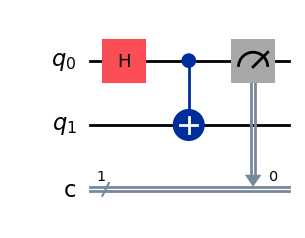

Measurement Counts:
{'0': 491, '1': 533}


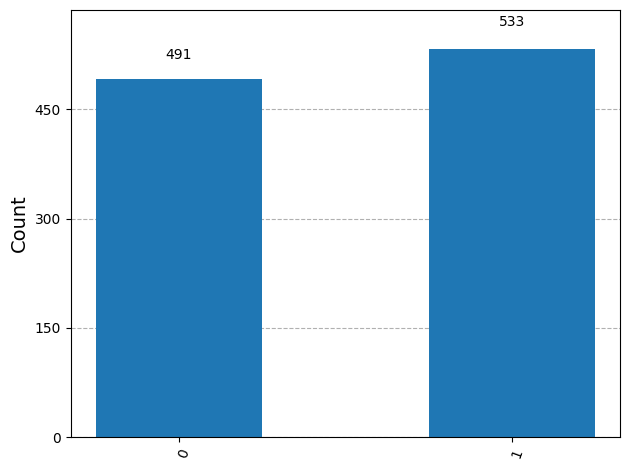

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

# ------------------------------------
# Create Bell State
# ------------------------------------

qc = QuantumCircuit(2, 1)

qc.h(0)
qc.cx(0, 1)

# Measure ONLY the first qubit
qc.measure(0, 0)

print("Bell State - Measuring Only Qubit 0\n")
display(qc.draw("mpl"))

# ------------------------------------
# Run Simulation
# ------------------------------------

sim = AerSimulator()

result = sim.run(qc, shots=1024).result()

counts = result.get_counts()

print("Measurement Counts:")
print(counts)

display(plot_histogram(counts))

Demo 5 – Exploring Different Bell States
Objective

Show that there are multiple Bell states.

By adding an X or Z gate, we can create different entangled states.

Students will observe that although the measurement probabilities may look similar, the underlying quantum state is different.

Bell State 1 (Φ⁺)

This is the Bell state they've already seen.

Circuit
q0 ───H────●────M
           │
q1 ────────X────M

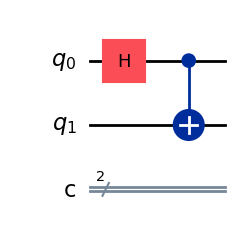

Statevector:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Counts:
{'11': 507, '00': 517}


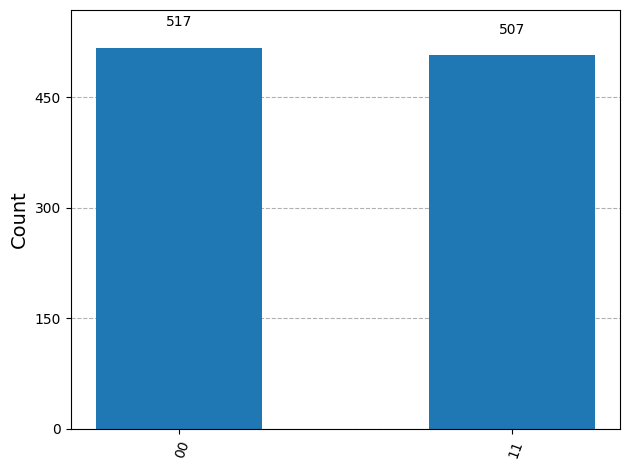

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display

sim = AerSimulator()

qc = QuantumCircuit(2,2)

qc.h(0)
qc.cx(0,1)

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print("Statevector:")
print(state)

qc.measure([0,1],[0,1])

result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print("\nCounts:")
print(counts)

display(plot_histogram(counts))

Bell State 2 (Ψ⁺)

Now add X before the Hadamard.

Circuit
q0 ───X────H────●────M
                │
q1 ─────────────X────M

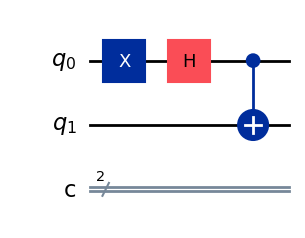

Statevector:
Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))

Counts:
{'00': 519, '11': 505}


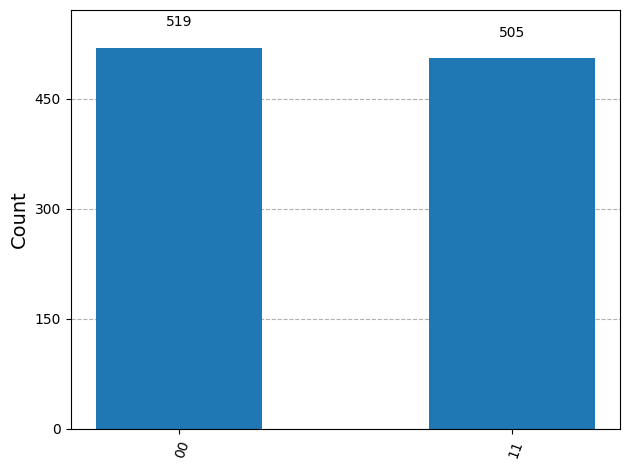

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display

sim = AerSimulator()

qc = QuantumCircuit(2,2)

qc.x(0)
qc.h(0)
qc.cx(0,1)

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print("Statevector:")
print(state)

qc.measure([0,1],[0,1])

result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print("\nCounts:")
print(counts)

display(plot_histogram(counts))

Bell State 3 (Φ⁻)

Now apply Z after creating the Bell state.

Circuit
q0 ───H────●────Z────M
           │
q1 ────────X─────────M

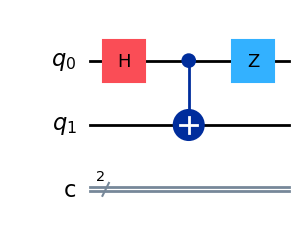

Statevector:
Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))

Counts:
{'00': 515, '11': 509}


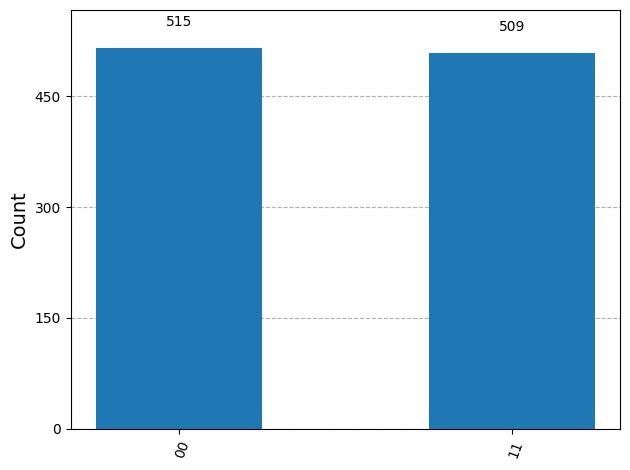

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display

sim = AerSimulator()

qc = QuantumCircuit(2,2)

qc.h(0)
qc.cx(0,1)
qc.z(0)

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print("Statevector:")
print(state)

qc.measure([0,1],[0,1])

result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print("\nCounts:")
print(counts)

display(plot_histogram(counts))

Bell State 4 (Ψ⁻)

Now combine X and Z.

Circuit
q0 ───X────H────●────Z────M
                │
q1 ─────────────X─────────M

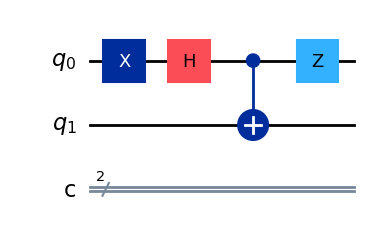

Statevector:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Counts:
{'11': 508, '00': 516}


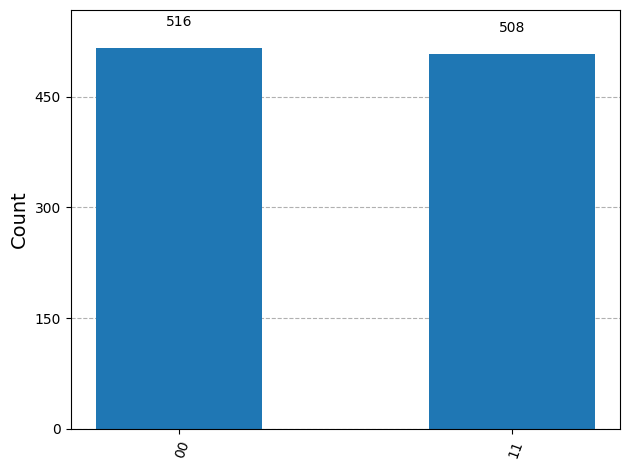

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display

sim = AerSimulator()

qc = QuantumCircuit(2,2)

qc.x(0)
qc.h(0)
qc.cx(0,1)
qc.z(0)

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print("Statevector:")
print(state)

qc.measure([0,1],[0,1])

result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print("\nCounts:")
print(counts)

display(plot_histogram(counts))

# Mini Challenge
### Create a Bell state that only produces 01 and 10 without copying the previous code? Which gate would you add, and where would you place it?